# ❤️ EDA03 - Heart Health Analysis

## Project Overview

Heart disease is one of the leading causes of death worldwide. Early identification of high-risk patients through data analysis can significantly improve treatment outcomes and reduce mortality. This project performs an Exploratory Data Analysis (EDA) on a heart disease dataset to identify the major risk factors associated with heart disease and provide meaningful insights that support better healthcare decisions.

The analysis focuses on patient demographics, clinical measurements, and medical history to understand the factors contributing to heart disease and to support preventive healthcare strategies.

---

## Problem Statement

HealthPulse Analytics aims to analyze patient health records to identify the key factors contributing to heart disease. The objective is to understand patient characteristics, clinical measurements, and medical conditions associated with heart disease so that healthcare providers can improve early diagnosis and preventive care.

---

## Objectives

- Perform data cleaning and preprocessing.
- Analyze patient demographics and clinical measurements.
- Identify significant heart disease risk factors.
- Explore relationships between medical attributes.
- Detect patterns associated with heart disease.
- Build a Logistic Regression model to predict heart disease.
- Generate meaningful visualizations and actionable insights.

---

## Stakeholders

### Internal Stakeholders

- Management Team
- Healthcare Providers
- Data Analysts

### External Stakeholders

- Patients
- Cardiology Research Institute
- Healthcare Policymakers

---

## Dataset Information

**Dataset Name:** Heart Disease Dataset

**Source:** Kaggle

The dataset contains patient demographic information, clinical measurements, and diagnostic indicators used to determine the presence or absence of heart disease.

In [2]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

plt.style.use("ggplot")
sns.set_style("whitegrid")

# Create Images folder
os.makedirs("Images3", exist_ok=True)

# Function to save plots
def save_plot(filename):
    plt.savefig(f"Images3/{filename}.png", dpi=300, bbox_inches="tight")

In [3]:
df = pd.read_csv("heart.csv")

# Data Understanding

Before performing exploratory data analysis, it is important to understand the structure, quality, and characteristics of the dataset. This section examines the dataset dimensions, data types, statistical summary, missing values, duplicate records, and unique values to identify any preprocessing required before analysis.

In [4]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [5]:
df.shape

(1025, 14)

In [6]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [8]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [9]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [10]:
(df.isnull().sum()/len(df))*100

age         0.0
sex         0.0
cp          0.0
trestbps    0.0
chol        0.0
fbs         0.0
restecg     0.0
thalach     0.0
exang       0.0
oldpeak     0.0
slope       0.0
ca          0.0
thal        0.0
target      0.0
dtype: float64

In [11]:
df.duplicated().sum()

np.int64(723)

In [12]:
df.dtypes

age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

In [13]:
df.nunique()

age          41
sex           2
cp            4
trestbps     49
chol        152
fbs           2
restecg       3
thalach      91
exang         2
oldpeak      40
slope         3
ca            5
thal          4
target        2
dtype: int64

In [14]:
df.sample(5, random_state=42)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
527,62,0,0,124,209,0,1,163,0,0.0,2,0,2,1
359,53,0,2,128,216,0,0,115,0,0.0,2,0,0,1
447,55,1,0,160,289,0,0,145,1,0.8,1,1,3,0
31,50,0,1,120,244,0,1,162,0,1.1,2,0,2,1
621,48,1,0,130,256,1,0,150,1,0.0,2,2,3,0


# Data Cleaning and Preprocessing

Data cleaning is an essential step to ensure accurate and reliable analysis. This section checks for missing values, removes duplicate records, verifies data types, and prepares the dataset for exploratory data analysis and predictive modeling.

In [15]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [16]:
df.duplicated().sum()

np.int64(723)

In [18]:
df.drop_duplicates(inplace=True)

In [19]:
df.duplicated().sum()

np.int64(0)

In [20]:
print("Number of Rows :", df.shape[0])
print("Number of Columns :", df.shape[1])

Number of Rows : 302
Number of Columns : 14


# Data Type Verification

All columns are verified to ensure they have appropriate data types before performing statistical analysis and machine learning.

In [21]:
df.dtypes

age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

# Outlier Detection

Outlier detection is performed to identify unusually high or low values in numerical variables. Detecting outliers helps improve the reliability of statistical analysis and predictive modeling.

In [22]:
numerical_columns = ['age','trestbps','chol','thalach','oldpeak']

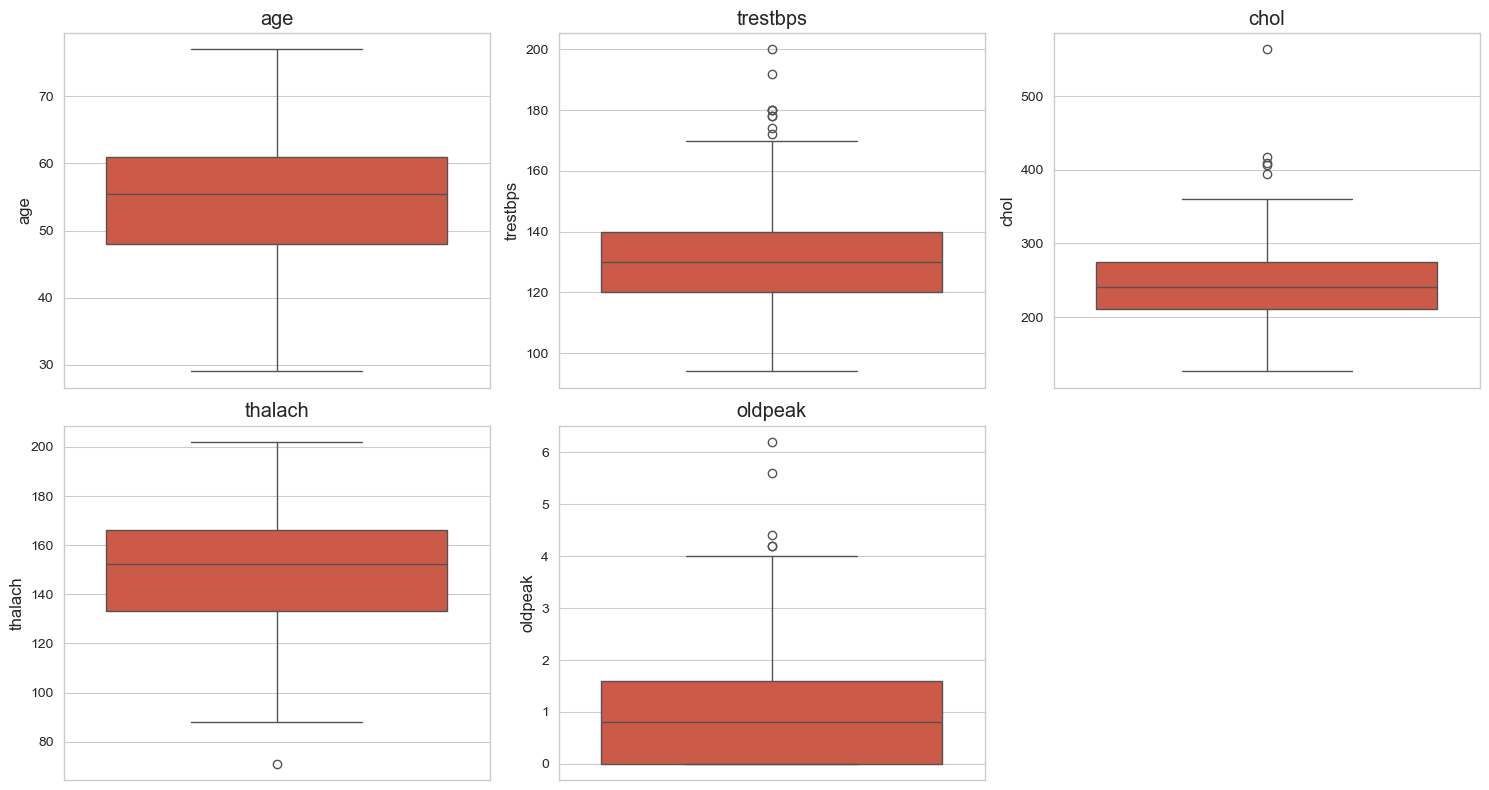

In [23]:
plt.figure(figsize=(15,8))

for i, col in enumerate(numerical_columns):
    plt.subplot(2,3,i+1)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()

save_plot("outlier_detection_boxplots")

plt.show()

# Feature Normalization

Normalization scales numerical variables to a common range, improving model performance and ensuring that features with larger values do not dominate the analysis.

In [24]:
from sklearn.preprocessing import MinMaxScaler

In [25]:
scaler = MinMaxScaler()

In [26]:
scaled_columns = ['age','trestbps','chol','thalach','oldpeak']

In [27]:
df[scaled_columns] = scaler.fit_transform(df[scaled_columns])

In [28]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,0.479167,1,0,0.292453,0.196347,0,1,0.740458,0,0.161290,2,2,3,0
1,0.500000,1,0,0.433962,0.175799,1,0,0.641221,1,0.500000,0,0,3,0
2,0.854167,1,0,0.481132,0.109589,0,1,0.412214,1,0.419355,0,0,3,0
3,0.666667,1,0,0.509434,0.175799,0,1,0.687023,0,0.000000,2,1,3,0
4,0.687500,0,0,0.415094,0.383562,1,1,0.267176,0,0.306452,1,3,2,0


# Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is performed to understand patient demographics, clinical measurements, and risk factors associated with heart disease. This analysis answers the business questions provided in the case study using statistical methods and visualizations to identify patterns that support early diagnosis and preventive healthcare.

In [29]:
# Question 1: Average Age of Patients

average_age = df['age'].mean()

print(f"Average Age : {average_age:.2f}")

Average Age : 0.53


In [30]:
# Question 2: Gender Distribution

gender_distribution = df['sex'].value_counts()

gender_distribution

sex
1    206
0     96
Name: count, dtype: int64

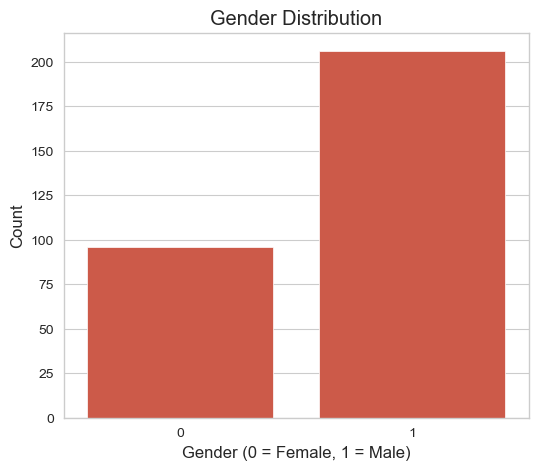

In [31]:
plt.figure(figsize=(6,5))

sns.countplot(data=df, x='sex')

plt.title("Gender Distribution")
plt.xlabel("Gender (0 = Female, 1 = Male)")
plt.ylabel("Count")

save_plot("gender_distribution")

plt.show()

In [32]:
# Question 3: Average Resting Blood Pressure

average_bp = df['trestbps'].mean()

print(f"Average Resting Blood Pressure : {average_bp:.2f}")

Average Resting Blood Pressure : 0.35


In [33]:
# Question 4: High Fasting Blood Sugar

high_fbs = df['fbs'].sum()

print(f"Patients with High Fasting Blood Sugar : {high_fbs}")

Patients with High Fasting Blood Sugar : 45


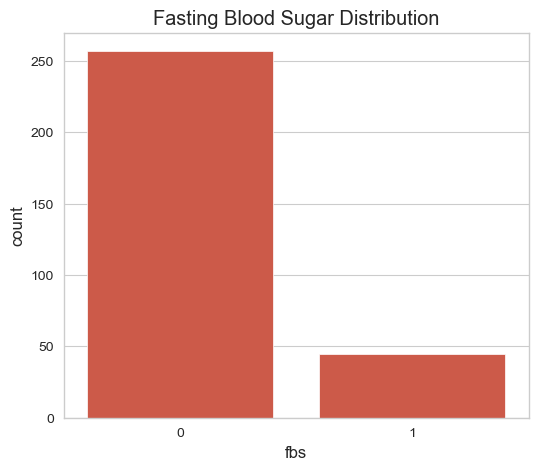

In [34]:
plt.figure(figsize=(6,5))

sns.countplot(data=df, x='fbs')

plt.title("Fasting Blood Sugar Distribution")

save_plot("fasting_blood_sugar_distribution")

plt.show()

In [35]:
# Question 5: Chest Pain Types

df['cp'].unique()

array([0, 1, 2, 3])

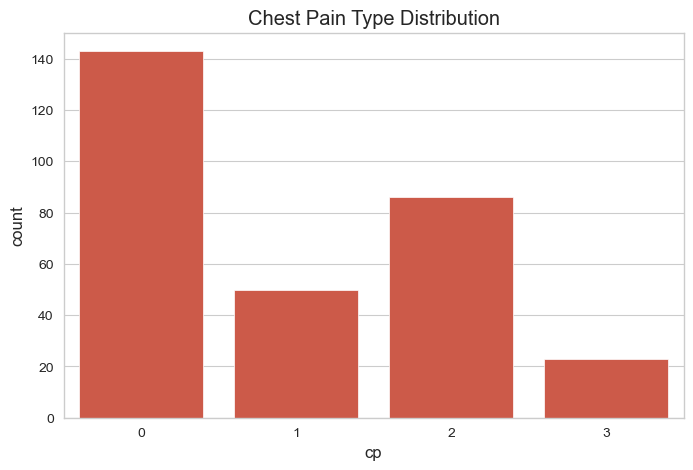

In [36]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x='cp')

plt.title("Chest Pain Type Distribution")

save_plot("chest_pain_type_distribution")

plt.show()

In [37]:
# Question 6: Maximum Heart Rate

max_hr = df['thalach'].max()

print(f"Maximum Heart Rate : {max_hr:.2f}")

Maximum Heart Rate : 1.00


In [38]:
# Question 7: Exercise-Induced Angina

angina_percentage = df['exang'].mean()*100

print(f"Exercise-Induced Angina : {angina_percentage:.2f}%")

Exercise-Induced Angina : 32.78%


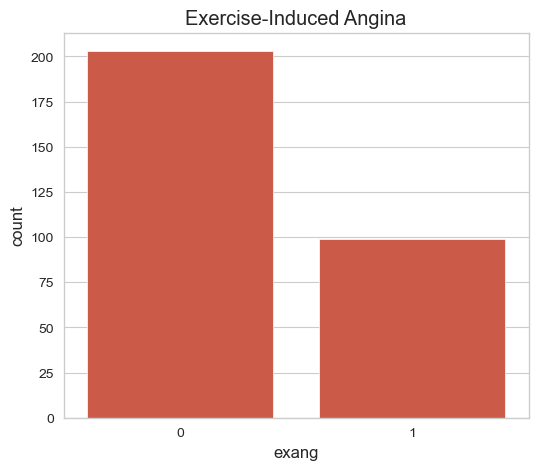

In [39]:
plt.figure(figsize=(6,5))

sns.countplot(data=df, x='exang')

plt.title("Exercise-Induced Angina")

save_plot("exercise_induced_angina")

plt.show()

In [40]:
# Question 8: Average Cholesterol Level

average_chol = df['chol'].mean()

print(f"Average Cholesterol : {average_chol:.2f}")

Average Cholesterol : 0.28


In [41]:
# Question 9: Resting ECG Result = 2

ecg_count = (df['restecg']==2).sum()

print(f"Patients with Rest ECG = 2 : {ecg_count}")

Patients with Rest ECG = 2 : 4


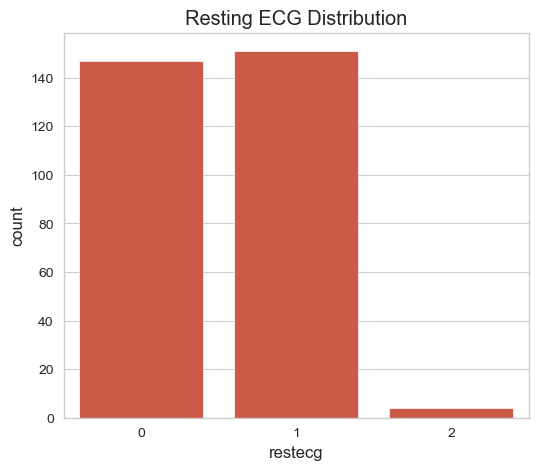

In [42]:
plt.figure(figsize=(6,5))

sns.countplot(data=df, x='restecg')

plt.title("Resting ECG Distribution")

save_plot("resting_ecg_distribution")

plt.show()

In [43]:
# Question 10: Major Vessels Distribution

vessel_distribution = df['ca'].value_counts()

vessel_distribution

ca
0    175
1     65
2     38
3     20
4      4
Name: count, dtype: int64

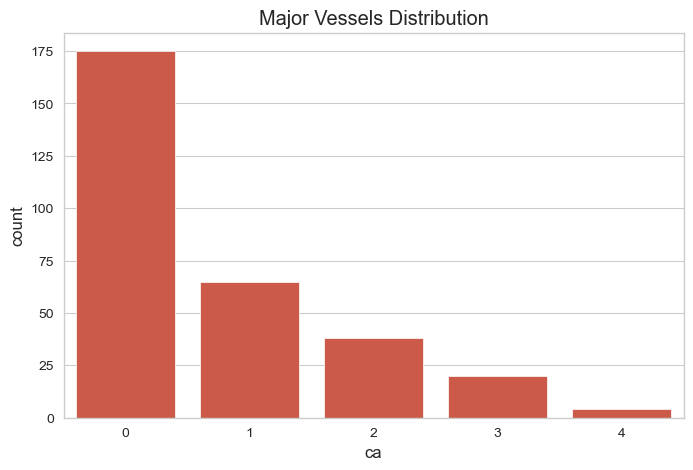

In [44]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x='ca')

plt.title("Major Vessels Distribution")

save_plot("major_vessels_distribution")

plt.show()

In [45]:
# Question 11: Correlation Between Age and Cholesterol

correlation = df[['age','chol']].corr()

correlation

,age,chol
age,1.000000,0.207216
chol,0.207216,1.000000


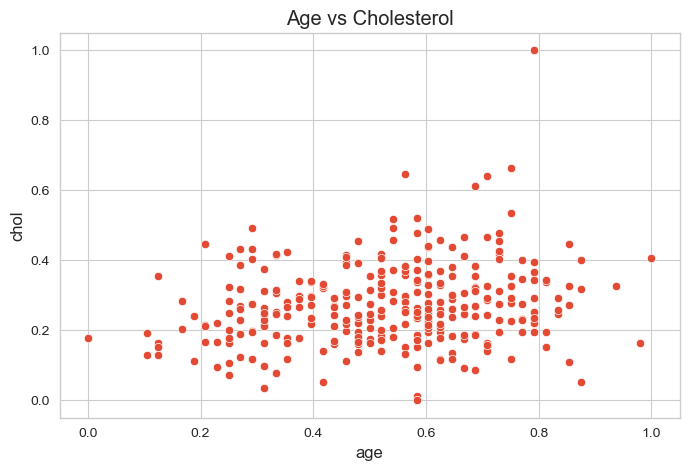

In [46]:
plt.figure(figsize=(8,5))

sns.scatterplot(data=df, x='age', y='chol')

plt.title("Age vs Cholesterol")

save_plot("age_vs_cholesterol")

plt.show()

In [47]:
# Question 12: Chest Pain Distribution Across Age

chest_pain_age = pd.crosstab(df['age'], df['cp'])

chest_pain_age.head()

cp,0,1,2,3
age,,,,
0.000000,0,1,0,0
0.104167,0,1,0,1
0.125000,3,1,0,0
0.166667,0,0,2,0
0.187500,0,0,1,1


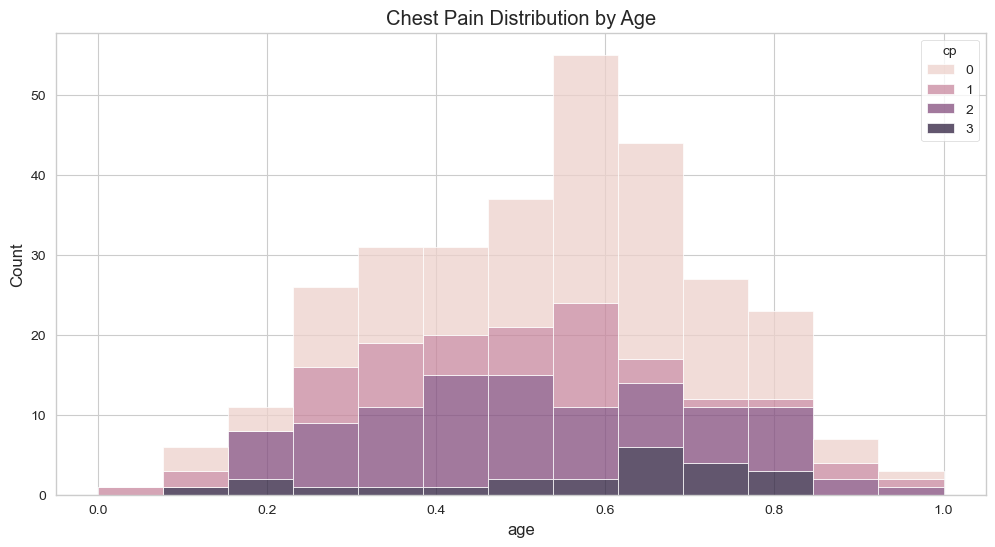

In [48]:
plt.figure(figsize=(12,6))

sns.histplot(data=df, x='age', hue='cp', multiple='stack')

plt.title("Chest Pain Distribution by Age")

save_plot("chest_pain_distribution_by_age")

plt.show()

In [49]:
# Question 13: Heart Rate by Exercise-Induced Angina

heart_rate = df.groupby('exang')['thalach'].mean()

heart_rate

exang
0    0.645771
1    0.505436
Name: thalach, dtype: float64

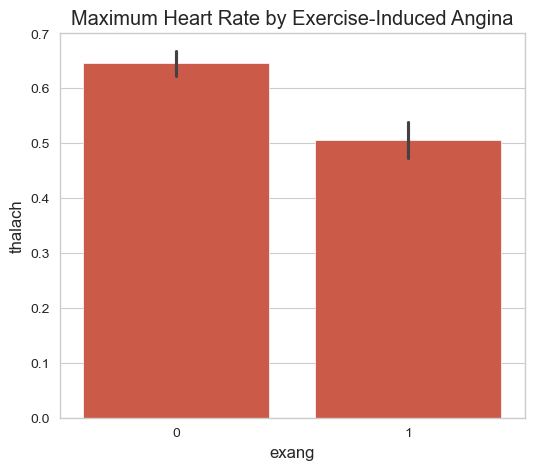

In [50]:
plt.figure(figsize=(6,5))

sns.barplot(data=df, x='exang', y='thalach', estimator='mean')

plt.title("Maximum Heart Rate by Exercise-Induced Angina")

save_plot("heart_rate_by_angina")

plt.show()

In [51]:
# Question 14: Resting Blood Pressure by Gender

blood_pressure = df.groupby('sex')['trestbps'].mean()

blood_pressure

sex
0    0.368711
1    0.348232
Name: trestbps, dtype: float64

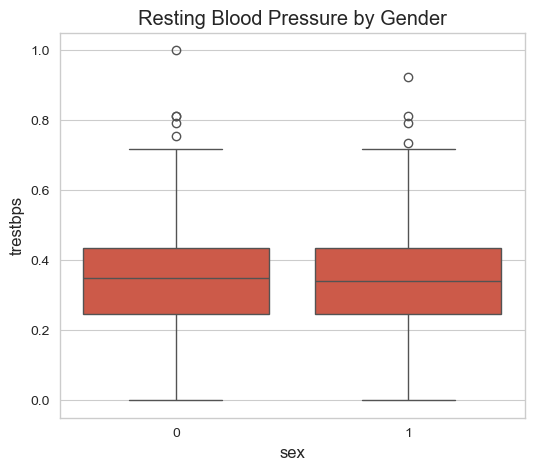

In [52]:
plt.figure(figsize=(6,5))

sns.boxplot(data=df, x='sex', y='trestbps')

plt.title("Resting Blood Pressure by Gender")

save_plot("resting_blood_pressure_by_gender")

plt.show()

In [53]:
# Question 15: Fasting Blood Sugar vs Heart Disease

blood_sugar = pd.crosstab(df['fbs'], df['target'])

blood_sugar

target,0,1
fbs,,
0,116,141
1,22,23


<Figure size 600x500 with 0 Axes>

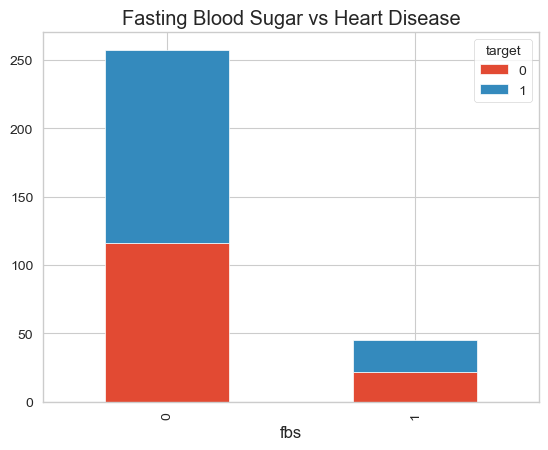

In [54]:
plt.figure(figsize=(6,5))

blood_sugar.plot(kind='bar', stacked=True)

plt.title("Fasting Blood Sugar vs Heart Disease")

save_plot("fasting_blood_sugar_vs_heart_disease")

plt.show()

In [55]:
# Question 16: Major Vessels vs Heart Disease

vessels = pd.crosstab(df['ca'], df['target'])

vessels

target,0,1
ca,,
0,45,130
1,44,21
2,31,7
3,17,3
4,1,3


<Figure size 800x500 with 0 Axes>

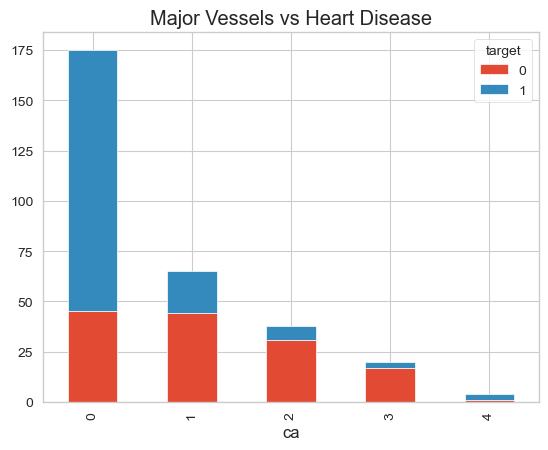

In [56]:
plt.figure(figsize=(8,5))

vessels.plot(kind='bar', stacked=True)

plt.title("Major Vessels vs Heart Disease")

save_plot("major_vessels_vs_heart_disease")

plt.show()

In [57]:
# Question 17: Average Oldpeak by Chest Pain Type

oldpeak = df.groupby('cp')['oldpeak'].mean()

oldpeak

cp
0    0.223099
1    0.050968
2    0.130158
3    0.224404
Name: oldpeak, dtype: float64

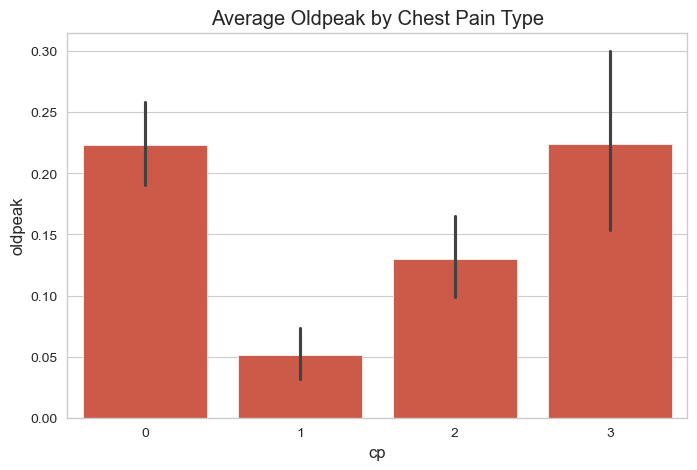

In [58]:
plt.figure(figsize=(8,5))

sns.barplot(data=df, x='cp', y='oldpeak', estimator='mean')

plt.title("Average Oldpeak by Chest Pain Type")

save_plot("average_oldpeak_by_chest_pain")

plt.show()

In [59]:
# Question 18: Thalassemia vs Heart Disease

thal = pd.crosstab(df['thal'], df['target'])

thal

target,0,1
thal,,
0,1,1
1,12,6
2,36,129
3,89,28


<Figure size 800x500 with 0 Axes>

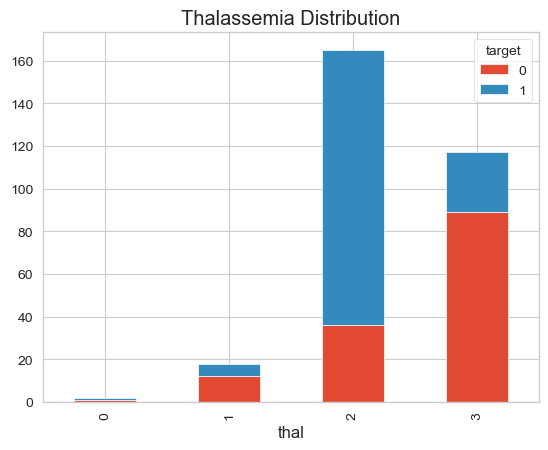

In [60]:
plt.figure(figsize=(8,5))

thal.plot(kind='bar', stacked=True)

plt.title("Thalassemia Distribution")

save_plot("thalassemia_distribution")

plt.show()

In [61]:
# Question 19: Common Risk Factor Combinations

risk = df[df['target']==1].groupby(
    ['cp','fbs','exang','thal']
).size().reset_index(name='Count')

risk.sort_values(by='Count', ascending=False).head(10)

,cp,fbs,exang,thal,Count
15,2,0,0,2,41
8,1,0,0,2,30
1,0,0,0,2,23
19,2,1,0,2,10
16,2,0,0,3,6
4,0,0,1,2,6
23,3,0,0,2,5
9,1,0,0,3,4
17,2,0,1,2,4
2,0,0,0,3,3


In [62]:
# Question 20: Clinical Measurement Comparison

df.groupby('target')[['age','trestbps','chol','thalach','oldpeak']].mean()

,age,trestbps,chol,thalach,oldpeak
target,,,,,
0,0.575030,0.381118,0.285587,0.519858,0.255727
1,0.491362,0.332547,0.266302,0.667008,0.094611


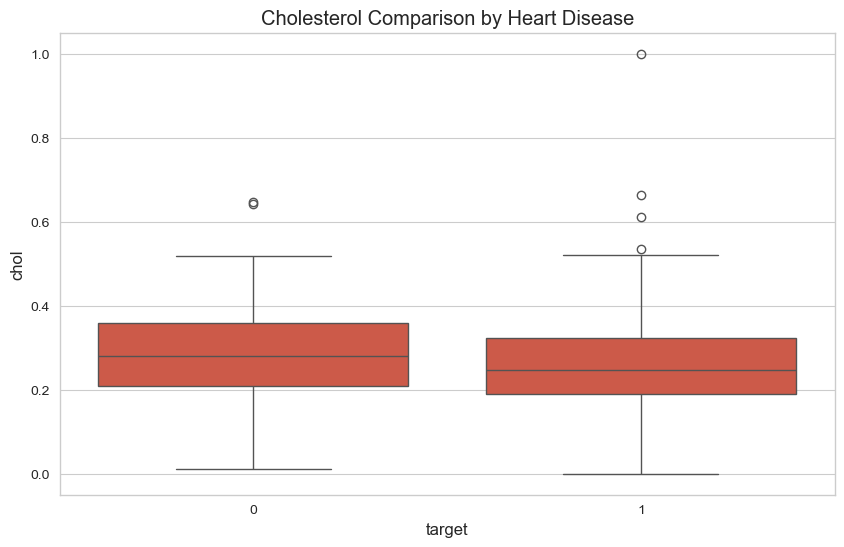

In [63]:
plt.figure(figsize=(10,6))

sns.boxplot(data=df, x='target', y='chol')

plt.title("Cholesterol Comparison by Heart Disease")

save_plot("cholesterol_comparison_by_heart_disease")

plt.show()

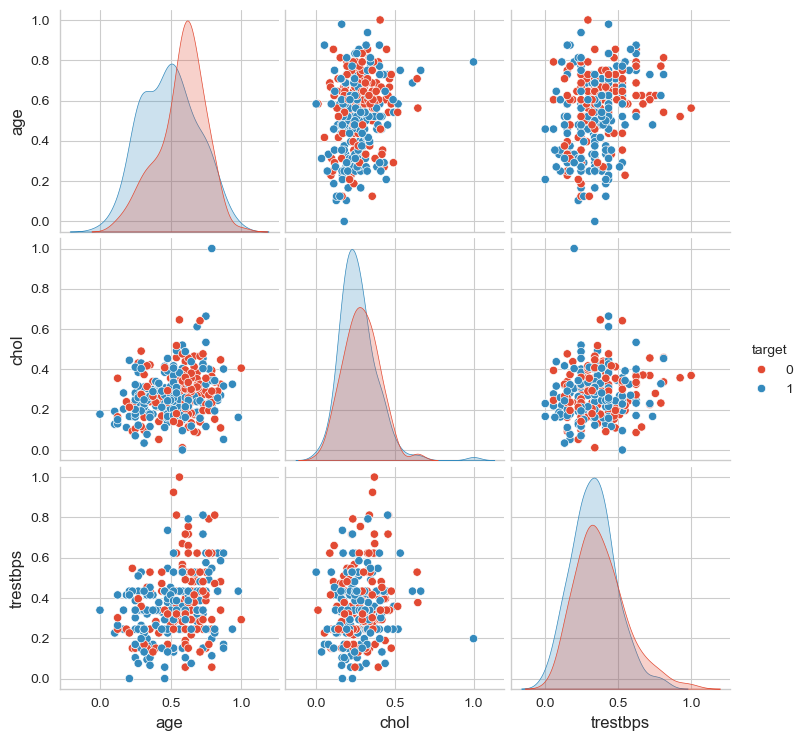

In [65]:
# Question 21: Combined Risk Factors and Heart Disease

sns.pairplot(
    df,
    vars=['age', 'chol', 'trestbps'],
    hue='target'
)

save_plot("combined_risk_factors_pairplot")

plt.show()

In [66]:
# Question 22: Correlation with Heart Disease

correlation = df.corr(numeric_only=True)

correlation['target'].sort_values(ascending=False)

target      1.000000
cp          0.432080
thalach     0.419955
slope       0.343940
restecg     0.134874
fbs        -0.026826
chol       -0.081437
trestbps   -0.146269
age        -0.221476
sex        -0.283609
thal       -0.343101
ca         -0.408992
oldpeak    -0.429146
exang      -0.435601
Name: target, dtype: float64

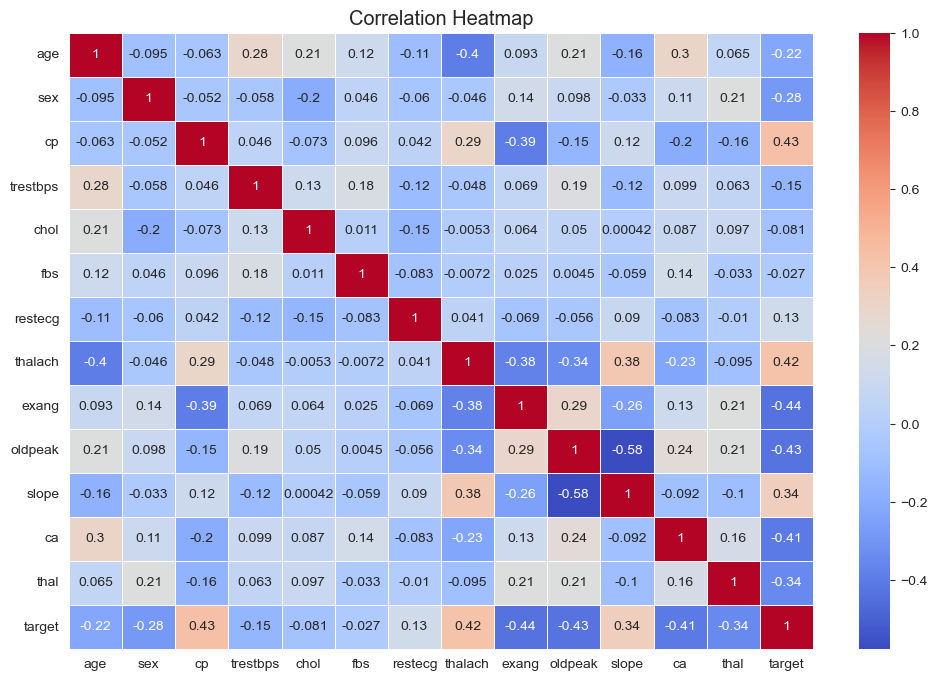

In [67]:
plt.figure(figsize=(12,8))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    linewidths=0.5
)

plt.title("Correlation Heatmap")

save_plot("correlation_heatmap")

plt.show()

In [68]:
# Question 23: Logistic Regression Model

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix\n")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report\n")
print(classification_report(y_test, y_pred))

Accuracy : 0.7868852459016393

Confusion Matrix

[[23  9]
 [ 4 25]]

Classification Report

              precision    recall  f1-score   support

           0       0.85      0.72      0.78        32
           1       0.74      0.86      0.79        29

    accuracy                           0.79        61
   macro avg       0.79      0.79      0.79        61
weighted avg       0.80      0.79      0.79        61



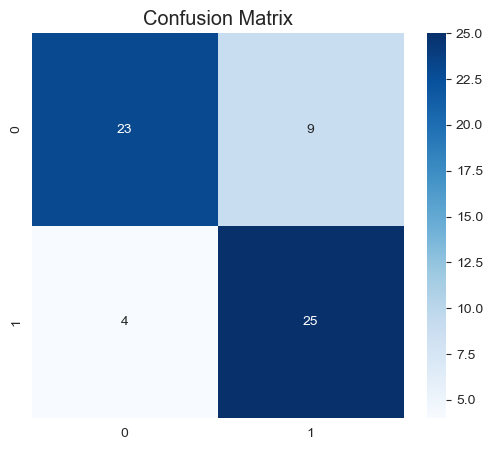

In [69]:
plt.figure(figsize=(6,5))

sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")

save_plot("confusion_matrix")

plt.show()

In [70]:
# Question 24: Slope vs Chest Pain Type

slope_cp = pd.crosstab(df['cp'], df['slope'])

slope_cp

slope,0,1,2
cp,,,
0,11,84,48
1,2,12,36
2,5,33,48
3,3,11,9


<Figure size 1000x600 with 0 Axes>

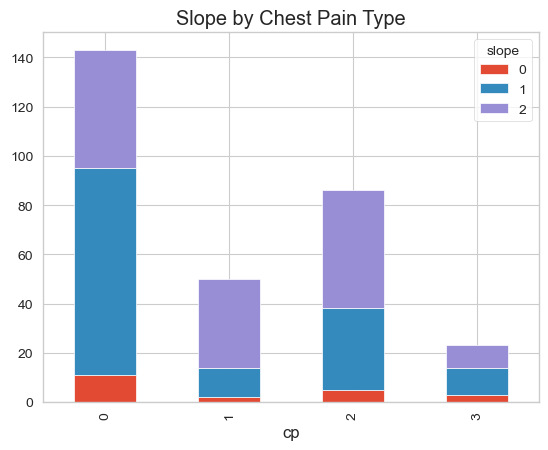

In [71]:
plt.figure(figsize=(10,6))

slope_cp.plot(kind='bar', stacked=True)

plt.title("Slope by Chest Pain Type")

save_plot("slope_by_chest_pain_type")

plt.show()

In [72]:
# Question 25: Thalassemia Analysis

thal_analysis = pd.crosstab(df['thal'], df['target'])

thal_analysis

target,0,1
thal,,
0,1,1
1,12,6
2,36,129
3,89,28


<Figure size 800x500 with 0 Axes>

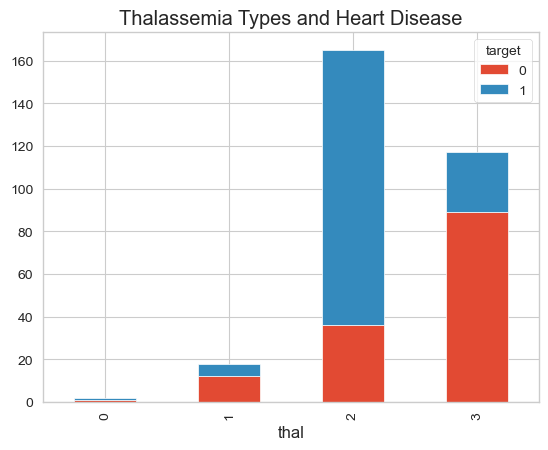

In [73]:
plt.figure(figsize=(8,5))

thal_analysis.plot(kind='bar', stacked=True)

plt.title("Thalassemia Types and Heart Disease")

save_plot("thalassemia_vs_heart_disease")

plt.show()